# Borzoi Transfer Learning Pipeline

Step-by-step interactive walkthrough: DNA encoding → BigWig signal → genome tiling → dataset → model → training with live loss plots → evaluation graphs.

All heavy lifting lives in the `.py` modules — this notebook wires them together and visualises every stage.

---
## Step 0 — Colab setup

Run **only on Colab**. Skip on local runs.

These cells:
- install runtime deps
- mount Google Drive
- copy hg38 + BigWigs from `MyDrive/borzoi_data/` → `/content/data/` (fast SSD I/O during training)
- symlink HuggingFace cache to Drive so the 4 Borzoi backbones are downloaded once and reused across sessions

Before running: **Runtime → Change runtime type → GPU (A100 / L4 / V100)**, and make sure your Drive has the expected layout (see Step 0c assertions).


In [ ]:
# Cell A — install runtime deps (numpy / torch / matplotlib / scipy already on Colab)
!pip install -q pyBigWig pyfaidx borzoi-pytorch tqdm


In [ ]:
# Cell B — mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell C — copy data + .py modules from Drive to /content (fast SSD)
import os, shutil
DRIVE_DATA = '/content/drive/MyDrive/borzoi_data'
DRIVE_CODE = '/content/drive/MyDrive/borzoi_code'    # .py modules
LOCAL_DATA = '/content/data'

# Sanity check the Drive layout before copying
assert os.path.isfile(f'{DRIVE_DATA}/hg38/hg38.ml.fa'),     f'Missing {DRIVE_DATA}/hg38/hg38.ml.fa'
assert os.path.isfile(f'{DRIVE_DATA}/hg38/hg38.ml.fa.fai'), f'Missing {DRIVE_DATA}/hg38/hg38.ml.fa.fai'
assert os.path.isdir(f'{DRIVE_DATA}/CRC_TFs_bw'),           f'Missing {DRIVE_DATA}/CRC_TFs_bw/ folder'
assert os.path.isdir(DRIVE_CODE),                            f'Missing {DRIVE_CODE} folder (upload the 8 .py modules here)'

os.makedirs(f'{LOCAL_DATA}/hg38', exist_ok=True)
os.makedirs(f'{LOCAL_DATA}/CRC_TFs_bw', exist_ok=True)

# Copy FASTA + index (skip if already present from a prior session)
for fn in ['hg38.ml.fa', 'hg38.ml.fa.fai']:
    src = f'{DRIVE_DATA}/hg38/{fn}'
    dst = f'{LOCAL_DATA}/hg38/{fn}'
    if not os.path.exists(dst):
        print(f'cp {fn} ...')
        shutil.copy(src, dst)

# Copy all BigWigs (cp -n skips existing files)
!cp -nr {DRIVE_DATA}/CRC_TFs_bw/. {LOCAL_DATA}/CRC_TFs_bw/

# Copy .py modules to /content/ (always overwrite — modules are small + may have updates)
!cp -f {DRIVE_CODE}/*.py /content/

# Report
import glob
bws = sorted(glob.glob(f'{LOCAL_DATA}/CRC_TFs_bw/*.bw'))
pys = sorted(glob.glob('/content/*.py'))
print(f'\nReady:')
print(f'  FASTA       : {LOCAL_DATA}/hg38/hg38.ml.fa  ({os.path.getsize(f"{LOCAL_DATA}/hg38/hg38.ml.fa")/1e9:.2f} GB)')
print(f'  BigWigs     : {len(bws)} files  ({sum(os.path.getsize(p) for p in bws)/1e9:.2f} GB)')
print(f'  .py modules : {len(pys)} files  ({[p.split("/")[-1] for p in pys]})')
free_gb = shutil.disk_usage('/content').free / 1e9
print(f'  Free /content: {free_gb:.1f} GB')
assert free_gb > 15, 'Less than 15 GB free on /content/ — risky for checkpoint writes + HF cache'



Ready:
  FASTA       : /content/data/hg38/hg38.ml.fa  (3.09 GB)
  BigWigs     : 169 files  (31.75 GB)
  .py modules : 13 files  (['bigwig_loader.py', 'config.py', 'dataset.py', 'fasta_reader.py', 'genome_tiler.py', 'main.py', 'model.py', 'plot.py', 'run.py', 'scratch.py', 'sequence_utils.py', 'test_setup.py', 'train.py'])
  Free /content: 150.8 GB


In [ ]:
# Cell D — symlink HuggingFace cache to Drive (so Borzoi backbones download once, reuse forever)
import os
HF_CACHE_DRIVE = '/content/drive/MyDrive/hf_cache'
HF_CACHE_LOCAL = '/root/.cache/huggingface'

os.makedirs(HF_CACHE_DRIVE, exist_ok=True)
if os.path.exists(HF_CACHE_LOCAL) and not os.path.islink(HF_CACHE_LOCAL):
    import shutil; shutil.rmtree(HF_CACHE_LOCAL)
if not os.path.exists(HF_CACHE_LOCAL):
    os.makedirs(os.path.dirname(HF_CACHE_LOCAL), exist_ok=True)
    os.symlink(HF_CACHE_DRIVE, HF_CACHE_LOCAL)
print(f'HF cache → {HF_CACHE_DRIVE}')
!ls -la {HF_CACHE_LOCAL} 2>/dev/null | head -5


HF cache → /content/drive/MyDrive/hf_cache
lrwxrwxrwx 1 root root 31 May 22 06:16 /root/.cache/huggingface -> /content/drive/MyDrive/hf_cache


---
## Step 1 — Prerequisites

**Required files** — all must be in the same folder as this notebook:

| File | Purpose |
|---|---|
| `sequence_utils.py` | One-hot DNA encoder |
| `fasta_reader.py` | FASTA genome reader |
| `bigwig_loader.py` | BigWig signal loader |
| `genome_tiler.py` | Tiles genome into windows |
| `dataset.py` | PyTorch Dataset |
| `model.py` | Frozen Borzoi + trainable head |
| `train.py` | Training loop |
| `config.py` | Path configuration |

**Required packages** (install once inside your venv):
```bash
pip install numpy torch pyfaidx pyBigWig borzoi-pytorch tqdm matplotlib scipy jupyter
```

---
## Step 2 — Verify environment

In [ ]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import pyBigWig
import pyfaidx
from pathlib import Path

from sequence_utils import one_hot_encode, reverse_complement
from fasta_reader import FastaReader
from bigwig_loader import BigWigLoader
from genome_tiler import tile_genome, Interval
from dataset import GenomicDataset
from model import BorzoiTransferModel

print('All imports OK')
print(f'NumPy   {np.__version__}')
print(f'PyTorch {torch.__version__}')

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

All imports OK
NumPy   2.0.2
PyTorch 2.10.0+cpu
Device: cpu


---
## Step 3 — Configure paths

Edit `config.py` to point `FASTA` and `BW_FILES` at your local files. The cell below just prints what config resolved to.

In [ ]:
from config import FASTA, BW_FILES

print(f'FASTA : {FASTA}')
print(f'Tracks: {len(BW_FILES)} BigWig files')
for p in BW_FILES[:5]:
    exists = Path(p).exists()
    print(f'  {"OK" if exists else "MISSING":7s}  {p}')
if len(BW_FILES) > 5:
    print(f'  ... and {len(BW_FILES)-5} more')

FASTA : /content/data/hg38/hg38.ml.fa
Tracks: 169 BigWig files
  OK       /content/data/CRC_TFs_bw/1151.bw
  OK       /content/data/CRC_TFs_bw/1152.bw
  OK       /content/data/CRC_TFs_bw/34078.bw
  OK       /content/data/CRC_TFs_bw/34398.bw
  OK       /content/data/CRC_TFs_bw/34399.bw
  ... and 164 more


---
## Step 5 — BigWig signal

Loads a window from `test.bw` (already in this folder) and plots the binned signal.  
This is what the model learns to predict.

In [ ]:
import pyBigWig, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BW_DEMO = BW_FILES[0]
bw = pyBigWig.open(BW_DEMO)

window = 50_000
bin_size = 32
n_bins = window // bin_size

found = False

for chrom, length in bw.chroms().items():
    if length < window:
        continue

    # scan first 20 Mb of each chromosome in 50 kb chunks
    max_scan = min(length - window, 20_000_000)

    for start in range(0, max_scan, window):
        end = start + window

        vals = bw.stats(chrom, start, end, type="mean", nBins=n_bins)
        vals = np.array([v if v is not None else 0.0 for v in vals], dtype=np.float32)

        if vals.max() > 0:
            found = True
            print(f"Found signal: {chrom}:{start:,}-{end:,}")
            print(f"max={vals.max():.3f}, mean={vals.mean():.3f}, nonzero={np.count_nonzero(vals)}/{n_bins}")
            break

    if found:
        break

bw.close()

Found signal: chr13:18,150,000-18,200,000
max=0.210, mean=0.009, nonzero=173/1562


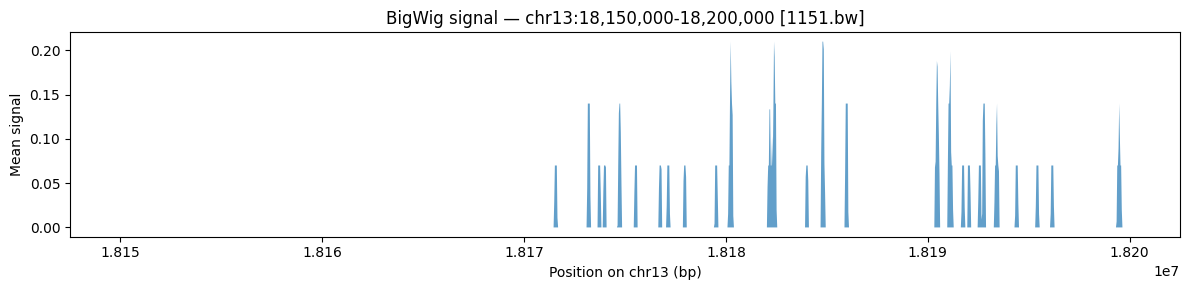

In [ ]:
genomic_pos = np.linspace(start, end, n_bins)

fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(genomic_pos, vals, alpha=0.7)
ax.set_xlabel(f"Position on {chrom} (bp)")
ax.set_ylabel("Mean signal")
ax.set_title(f"BigWig signal — {chrom}:{start:,}-{end:,} [{Path(BW_DEMO).name}]")
plt.tight_layout()
plt.show()

---
## Step 4 — DNA encoding

One-hot encodes a sequence: each base becomes a column in a (seq_len × 4) matrix.  
Row order: **A C G T**. Unknown bases (N) are all-zero.

In [ ]:
from fasta_reader import FastaReader


fasta = FastaReader(FASTA)

example_seq = fasta.fetch(chrom, start, end)

encoded = one_hot_encode(example_seq)   # (10, 4)

print(f'Sequence : {example_seq}')
print(f'RC       : {reverse_complement(example_seq)}')
print(f'Shape    : {encoded.shape}  (positions x bases)')

Sequence : ...
RC       : ...
Shape    : (50000, 4)  (positions x bases)


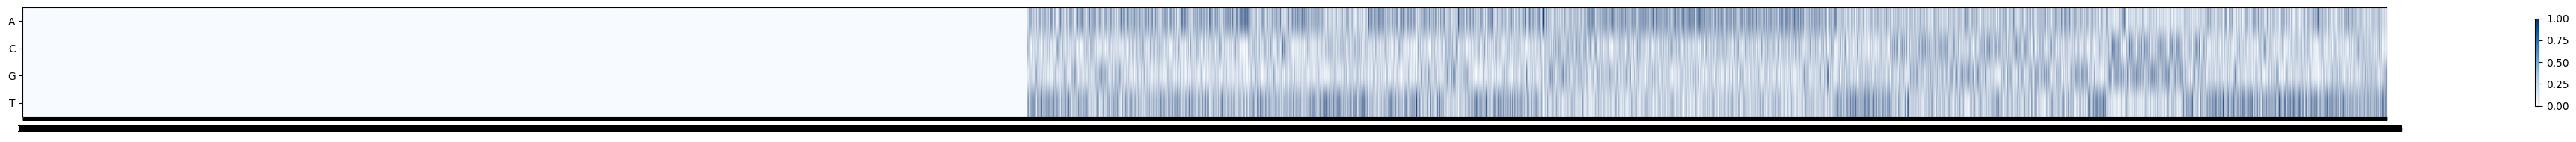

In [ ]:
fig, ax = plt.subplots(figsize=(40, 2))
im = ax.imshow(encoded.T, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['A', 'C', 'G', 'T'])
ax.set_xticks(range(len(example_seq)))
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---
## Step 6 — Tile the genome

Slides a 524,288 bp window across every chromosome and assigns each window to train / val / test.  
Val = chr1, chr8 · Test = chr9, chr22 · Train = everything else.

train: 4659 intervals
val: 750 intervals
test: 359 intervals


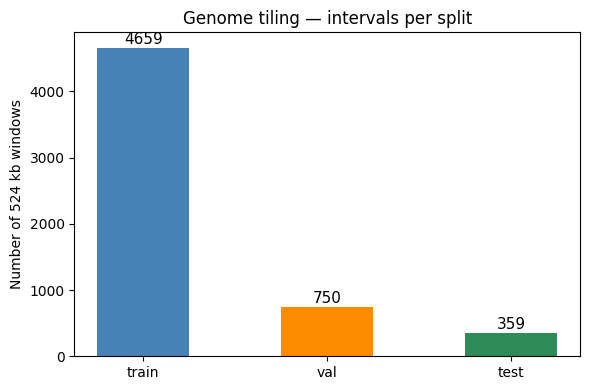

In [ ]:
splits = tile_genome(FASTA)   # default split: val=chr1/chr8, test=chr9/chr22

split_names  = list(splits.keys())
split_counts = [len(splits[s]) for s in split_names]

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['steelblue', 'darkorange', 'seagreen']
bars = ax.bar(split_names, split_counts, color=colors, width=0.5)
for bar, count in zip(bars, split_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Number of 524 kb windows')
ax.set_title('Genome tiling — intervals per split')
plt.tight_layout()
plt.show()

In [ ]:
#find corrupted .bw file
import os
import pyBigWig

print("BW count:", len(BW_FILES))

bad = []

for p in BW_FILES:
    try:
        bw = pyBigWig.open(p)
        bw.chroms()
        bw.close()
    except Exception as e:
        bad.append((p, str(e)))

print("Bad files:", len(bad))

for x in bad[:10]:
    print(x)

BW count: 169
Bad files: 2
('/content/data/CRC_TFs_bw/1152.bw', 'Received an error during file opening!')
('/content/data/CRC_TFs_bw/81159.bw', 'Received an error during file opening!')


In [ ]:
print([p for p in BW_FILES])

['/content/data/CRC_TFs_bw/1151.bw', '/content/data/CRC_TFs_bw/1152.bw', '/content/data/CRC_TFs_bw/34078.bw', '/content/data/CRC_TFs_bw/34398.bw', '/content/data/CRC_TFs_bw/34399.bw', '/content/data/CRC_TFs_bw/356.bw', '/content/data/CRC_TFs_bw/357.bw', '/content/data/CRC_TFs_bw/362.bw', '/content/data/CRC_TFs_bw/371.bw', '/content/data/CRC_TFs_bw/372.bw', '/content/data/CRC_TFs_bw/37565.bw', '/content/data/CRC_TFs_bw/38576.bw', '/content/data/CRC_TFs_bw/38585.bw', '/content/data/CRC_TFs_bw/38650.bw', '/content/data/CRC_TFs_bw/38653.bw', '/content/data/CRC_TFs_bw/38658.bw', '/content/data/CRC_TFs_bw/38663.bw', '/content/data/CRC_TFs_bw/38666.bw', '/content/data/CRC_TFs_bw/38691.bw', '/content/data/CRC_TFs_bw/38704.bw', '/content/data/CRC_TFs_bw/38712.bw', '/content/data/CRC_TFs_bw/38719.bw', '/content/data/CRC_TFs_bw/38724.bw', '/content/data/CRC_TFs_bw/38731.bw', '/content/data/CRC_TFs_bw/38758.bw', '/content/data/CRC_TFs_bw/38761.bw', '/content/data/CRC_TFs_bw/38763.bw', '/content/da

In [ ]:
#filter off bad file
BW_FILES = [p for p in BW_FILES if p not in [x[0] for x in bad]]
# TEMP speed test: use fewer BigWig tracks
BW_FILES = BW_FILES[:10]
print("Using BW files:", len(BW_FILES))

Using BW files: 10


In [ ]:
BW_FILES

['/content/data/CRC_TFs_bw/1151.bw',
 '/content/data/CRC_TFs_bw/34078.bw',
 '/content/data/CRC_TFs_bw/34398.bw',
 '/content/data/CRC_TFs_bw/34399.bw',
 '/content/data/CRC_TFs_bw/356.bw',
 '/content/data/CRC_TFs_bw/357.bw',
 '/content/data/CRC_TFs_bw/362.bw',
 '/content/data/CRC_TFs_bw/371.bw',
 '/content/data/CRC_TFs_bw/372.bw',
 '/content/data/CRC_TFs_bw/37565.bw']

---
## Step 7 — Dataset sample

Wraps the FASTA reader and BigWig loader into a PyTorch `Dataset`.  
Each item: one-hot sequence tensor + binned signal target tensor.

Train intervals: 4659
Val   intervals: 750
sequence shape : torch.Size([524288, 4])   (seq_len x 4)
targets  shape : torch.Size([4096, 10])    (center_bins x n_tracks)
interval       : Interval(chrom='chr10', start=0, end=524288, name='chr10_0_524288')


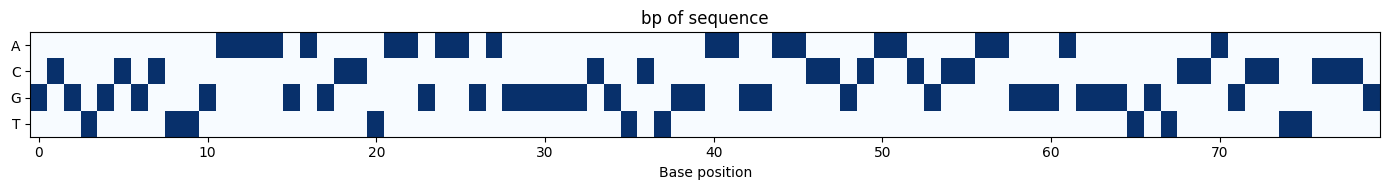

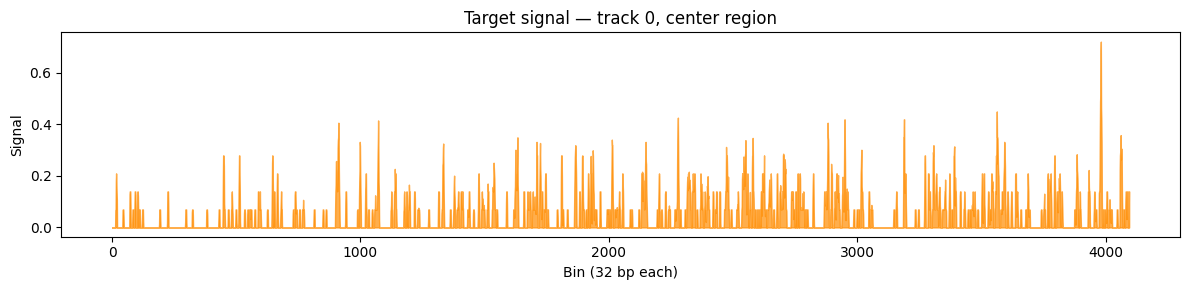

In [ ]:
bw_loader = BigWigLoader(BW_FILES, bin_size=32)
train_ds  = GenomicDataset(FASTA, splits['train'], bigwig_loader=bw_loader)
val_ds    = GenomicDataset(FASTA, splits['val'],   bigwig_loader=BigWigLoader(BW_FILES, bin_size=32))

print(f'Train intervals: {len(train_ds)}')
print(f'Val   intervals: {len(val_ds)}')

sample = train_ds[0]
print(f"sequence shape : {sample['sequence'].shape}   (seq_len x 4)")
print(f"targets  shape : {sample['targets'].shape}    (center_bins x n_tracks)")
print(f"interval       : {sample['interval']}")

# Show the first 200 bases as a one-hot heatmap
seq_snippet = sample['sequence'][11_000:11_080].numpy().T   # (4, 200)
fig, ax = plt.subplots(figsize=(14, 2))
ax.imshow(seq_snippet, aspect='auto', cmap='Blues', vmin=0, vmax=1)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['A', 'C', 'G', 'T'])
ax.set_xlabel('Base position')
ax.set_title(f"bp of sequence")
plt.tight_layout()
plt.show()

# Show target signal for track 0
tgt0 = sample['targets'][:, 0].numpy()
fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(range(len(tgt0)), tgt0, alpha=0.7, color='darkorange')
ax.set_xlabel('Bin (32 bp each)')
ax.set_ylabel('Signal')
ax.set_title('Target signal — track 0, center region')
plt.tight_layout()
plt.show()

---
## Step 8 — Load pretrained model

Downloads 4 Borzoi folds from HuggingFace (cached after first run — ~several GB).  
Backbone weights are frozen; only the small linear head is trainable.

In [ ]:
from tqdm.notebook import tqdm as tqdm_nb

n_tracks = len(BW_FILES)
print(f'Building model with {n_tracks} output tracks on {device} ...')
model = BorzoiTransferModel(n_output_tracks=n_tracks, device=device)

frozen_params    = sum(p.numel() for b in model.backbones for p in b.parameters())
trainable_params = sum(p.numel() for p in model.head.parameters())
print(f'Frozen backbone params : {frozen_params:,}')
print(f'Trainable head params  : {trainable_params:,}')
print(f'Head architecture      : {model.head}')

Building model with 10 output tracks on cpu ...
Loading fold 0 from HuggingFace: johahi/borzoi-replicate-0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading fold 1 from HuggingFace: johahi/borzoi-replicate-1
Loading fold 2 from HuggingFace: johahi/borzoi-replicate-2
Loading fold 3 from HuggingFace: johahi/borzoi-replicate-3
Frozen backbone params : 743,570,796
Trainable head params  : 76,120
Head architecture      : Sequential(
  (0): Linear(in_features=7611, out_features=10, bias=True)
  (1): Softplus(beta=1.0, threshold=20.0)
)


---
## Step 9 — Training with live plots

The training loop below:
- Shows a **tqdm** progress bar per epoch
- Redraws a **live loss curve** after every epoch
- Saves `model_head.pt` and `results/history.json` when done
- Saves `results/eval_preds.npy` / `results/eval_targets.npy` from the val set (used in Step 10)

In [ ]:
import json
import torch.nn.functional as F
from torch.utils.data import DataLoader
from IPython.display import clear_output

CKPT_DIR = '/content/drive/MyDrive/borzoi_ckpt'   # checkpoints land on Drive → crash-resilient
Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)


def train_resumable(model, train_dataset, val_dataset,
                    n_epochs=4, batch_size=1, lr=1e-4):
    optimizer = torch.optim.Adam(model.head.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': []}
    start_epoch = 0

    # ── resume from latest checkpoint if it exists ───────────────
    head_pt = Path(CKPT_DIR) / 'model_head.pt'
    if head_pt.exists():
        model.head.load_state_dict(torch.load(head_pt, map_location=model.device))
        opt_pt = Path(CKPT_DIR) / 'optimizer.pt'
        if opt_pt.exists():
            optimizer.load_state_dict(torch.load(opt_pt, map_location=model.device))
        ep_txt = Path(CKPT_DIR) / 'epoch.txt'
        if ep_txt.exists():
            start_epoch = int(ep_txt.read_text())
        hist_json = Path(CKPT_DIR) / 'history.json'
        if hist_json.exists():
            history = json.loads(hist_json.read_text())
        print(f'Resuming from epoch {start_epoch}  (history has {len(history["train_loss"])} train points)')
    else:
        print('No checkpoint found — starting from scratch')

    last_val_preds, last_val_targets = [], []

    for epoch in range(start_epoch, n_epochs):

        # ── train ──────────────────────────────────────────────
        model.head.train()
        epoch_losses = []
        pbar = tqdm_nb(DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
                       desc=f'Epoch {epoch+1}/{n_epochs} [train]', leave=False)
        for batch in pbar:
            seq = batch['sequence'].to(model.device)
            tgt = batch['targets'].to(model.device)
            pred = model(seq)
            loss = F.poisson_nll_loss(pred, tgt, log_input=False)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        history['train_loss'].append(float(np.mean(epoch_losses)))

        # ── val ────────────────────────────────────────────────
        model.head.eval()
        val_losses, ep_preds, ep_targets = [], [], []
        with torch.no_grad():
            for batch in tqdm_nb(DataLoader(val_dataset, batch_size=batch_size),
                                 desc=f'Epoch {epoch+1}/{n_epochs} [val]', leave=False):
                seq = batch['sequence'].to(model.device)
                tgt = batch['targets'].to(model.device)
                pred = model(seq)
                val_losses.append(F.poisson_nll_loss(pred, tgt, log_input=False).item())
                ep_preds.append(pred.cpu().numpy())
                ep_targets.append(tgt.cpu().numpy())
        history['val_loss'].append(float(np.mean(val_losses)))
        last_val_preds, last_val_targets = ep_preds, ep_targets

        # ── live loss curve ────────────────────────────────────
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 4))
        epochs_x = range(1, len(history['train_loss']) + 1)
        ax.plot(epochs_x, history['train_loss'], marker='o', label='train')
        if history['val_loss']:
            ax.plot(epochs_x, history['val_loss'], marker='o', label='val')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Poisson NLL Loss')
        ax.set_title('Training progress (resumable)')
        ax.legend()
        plt.tight_layout()
        plt.show()
        print(f"Epoch {epoch+1}/{n_epochs}  train={history['train_loss'][-1]:.4f}  val={history['val_loss'][-1]:.4f}")

        # ── checkpoint EVERY epoch to Drive ────────────────────
        torch.save(model.head.state_dict(), head_pt)
        torch.save(optimizer.state_dict(),  Path(CKPT_DIR) / 'optimizer.pt')
        (Path(CKPT_DIR) / 'epoch.txt').write_text(str(epoch + 1))
        (Path(CKPT_DIR) / 'history.json').write_text(json.dumps(history))
        print(f'  ✓ checkpoint saved to {CKPT_DIR} (epoch {epoch+1})')

    # ── final: also dump val preds locally for Step 10 ─────────
    Path('results').mkdir(exist_ok=True)
    if last_val_preds:
        np.save('results/eval_preds.npy',   np.concatenate(last_val_preds,   axis=0))
        np.save('results/eval_targets.npy', np.concatenate(last_val_targets, axis=0))
        # Also mirror history.json locally so Step 10 doesn't need Drive
        with open('results/history.json', 'w') as f:
            json.dump(history, f)
        print('Saved results/eval_preds.npy, eval_targets.npy, history.json')

    return history


history = train_resumable(model, train_ds, val_ds, n_epochs=4)


Resuming from epoch 4  (history has 4 train points)


## shortcut to saving "history"
loading files from checkpoint and running validation only once

In [ ]:
from pathlib import Path
import json, numpy as np, torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

CKPT_DIR = Path('/content/drive/MyDrive/borzoi_ckpt')

# 1. Load saved history from Drive
history = json.loads((CKPT_DIR / 'history.json').read_text())
print(history)

# 2. Confirm checkpoint epoch
saved_epoch = int((CKPT_DIR / 'epoch.txt').read_text())
print("Saved up to epoch:", saved_epoch)

{'train_loss': [0.19251294149976222, 0.1852746141469176, 0.18330380073155833, 0.18277488122501293], 'val_loss': [0.18092028430849313, 0.1782713521880408, 0.17669959735373655, 0.17890500254929065]}
Saved up to epoch: 4


In [ ]:
head_pt = CKPT_DIR / 'model_head.pt'
model.head.load_state_dict(torch.load(head_pt, map_location=model.device))
model.head.eval()

Sequential(
  (0): Linear(in_features=7611, out_features=10, bias=True)
  (1): Softplus(beta=1.0, threshold=20.0)
)

In [ ]:
Path('results').mkdir(exist_ok=True)

val_losses, ep_preds, ep_targets = [], [], []

model.head.eval()
with torch.no_grad():
    for batch in tqdm_nb(DataLoader(val_ds, batch_size=1), desc='Final eval'):
        seq = batch['sequence'].to(model.device)
        tgt = batch['targets'].to(model.device)

        pred = model(seq)

        loss = F.poisson_nll_loss(pred, tgt, log_input=False)
        val_losses.append(loss.item())

        ep_preds.append(pred.cpu().numpy())
        ep_targets.append(tgt.cpu().numpy())

eval_val_loss = float(np.mean(val_losses))
print("Eval val loss:", eval_val_loss)

np.save('results/eval_preds.npy', np.concatenate(ep_preds, axis=0))
np.save('results/eval_targets.npy', np.concatenate(ep_targets, axis=0))

with open('results/history.json', 'w') as f:
    json.dump(history, f)

print("Saved eval_preds.npy, eval_targets.npy, history.json")

Final eval:   0%|          | 0/750 [00:00<?, ?it/s]

---
## Step 10 — Evaluation plots

Four figures generated from the saved val-set predictions:
1. Loss curve (train vs val)
2. Per-track Pearson R
3. Predicted vs actual signal — top-3 tracks, first interval
4. Scatter — mean signal per interval × track

In [ ]:
from scipy.stats import pearsonr

preds   = np.load('results/eval_preds.npy')    # (n_intervals, center_bins, n_tracks)
targets = np.load('results/eval_targets.npy')
n_intervals, center_bins, n_tracks = preds.shape
print(f'Eval arrays loaded: {preds.shape}')

# ── 1. Loss curve ─────────────────────────────────────────────────
with open('results/history.json') as f:
    hist = json.load(f)

fig, ax = plt.subplots(figsize=(7, 4))
ep = range(1, len(hist['train_loss']) + 1)
ax.plot(ep, hist['train_loss'], marker='o', label='train')
if hist['val_loss']:
    ax.plot(ep, hist['val_loss'], marker='o', label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Poisson NLL Loss')
ax.set_title('Training curve')
ax.legend()
plt.tight_layout()
plt.show()

# ── 2. Per-track Pearson R ────────────────────────────────────────
p_flat    = preds.reshape(-1, n_tracks)
t_flat    = targets.reshape(-1, n_tracks)
pearson_r = np.array([pearsonr(p_flat[:, i], t_flat[:, i])[0] for i in range(n_tracks)])
order     = np.argsort(pearson_r)[::-1]

fig, ax = plt.subplots(figsize=(max(8, n_tracks * 0.2), 4))
ax.bar(range(n_tracks), pearson_r[order], width=1.0, color='steelblue')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Track (sorted by R)')
ax.set_ylabel('Pearson R')
ax.set_title(f'Per-track Pearson R  (mean={pearson_r.mean():.3f})')
ax.set_xticks([])
plt.tight_layout()
plt.show()

# ── 3. Predicted vs actual — top-3 tracks, first interval ─────────
top3 = order[:3]
x    = np.arange(center_bins)
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, ti in zip(axes, top3):
    r, _ = pearsonr(preds[0, :, ti], targets[0, :, ti])
    ax.plot(x, targets[0, :, ti], label='actual',    alpha=0.8, linewidth=0.8)
    ax.plot(x, preds[0,   :, ti], label='predicted', alpha=0.8, linewidth=0.8, linestyle='--')
    ax.set_ylabel('signal')
    ax.set_title(f'Track {ti}  (R={r:.3f})')
    ax.legend(fontsize=7, loc='upper right')
axes[-1].set_xlabel('Genomic bin (32 bp)')
fig.suptitle('Predicted vs actual — top-3 tracks, interval 0')
plt.tight_layout()
plt.show()

# ── 4. Scatter — mean signal per interval × track ─────────────────
p_mean   = preds.mean(axis=1).ravel()
t_mean   = targets.mean(axis=1).ravel()
r_all, _ = pearsonr(p_mean, t_mean)
fig, ax  = plt.subplots(figsize=(5, 5))
ax.scatter(t_mean, p_mean, s=4, alpha=0.3, rasterized=True)
lim = max(t_mean.max(), p_mean.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=0.8, label='y=x')
ax.set_xlabel('Actual mean signal')
ax.set_ylabel('Predicted mean signal')
ax.set_title(f'Predicted vs actual  (R={r_all:.3f})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'Mean Pearson R across {n_tracks} tracks: {pearson_r.mean():.4f}')